<a href="https://colab.research.google.com/github/ericyoc/dissertation_code_and_data/blob/main/visualizations_dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


CHARTS - COMPOUND ATTACKS VERSION

✓ Found 120 result files

✓ Extracted: 120 results
✓ Datasets: ['EMNIST Digits', 'MNIST', 'TinyImageNet', 'TrafficSigns']
✓ Categories: ['Adversarial Training', 'Input Transformation', 'Randomization']
✓ Attacks: ['CW+PGD', 'FGSM+CW', 'FGSM+PGD']

✓ Saving to: /content/drive/MyDrive/results/IEEE_charts/

Chart 1: Category Overview


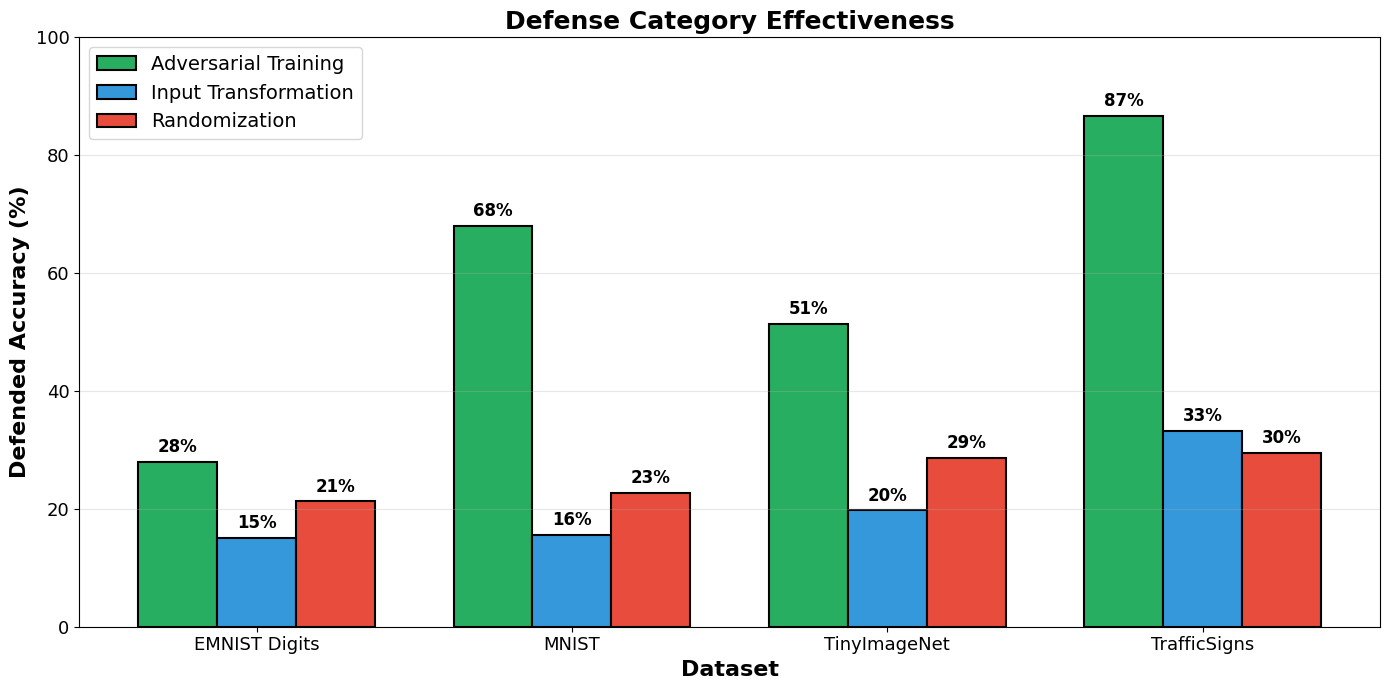

Chart 2: Input Transformation


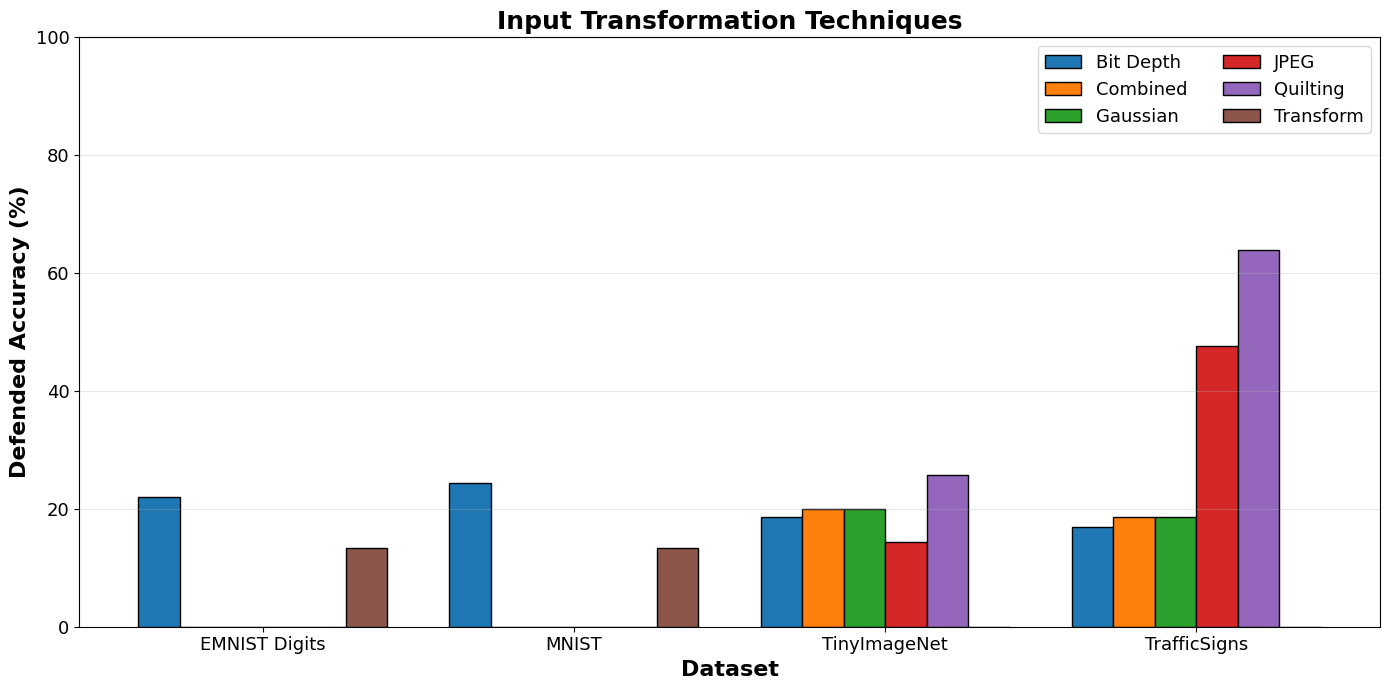

Chart 3: Randomization


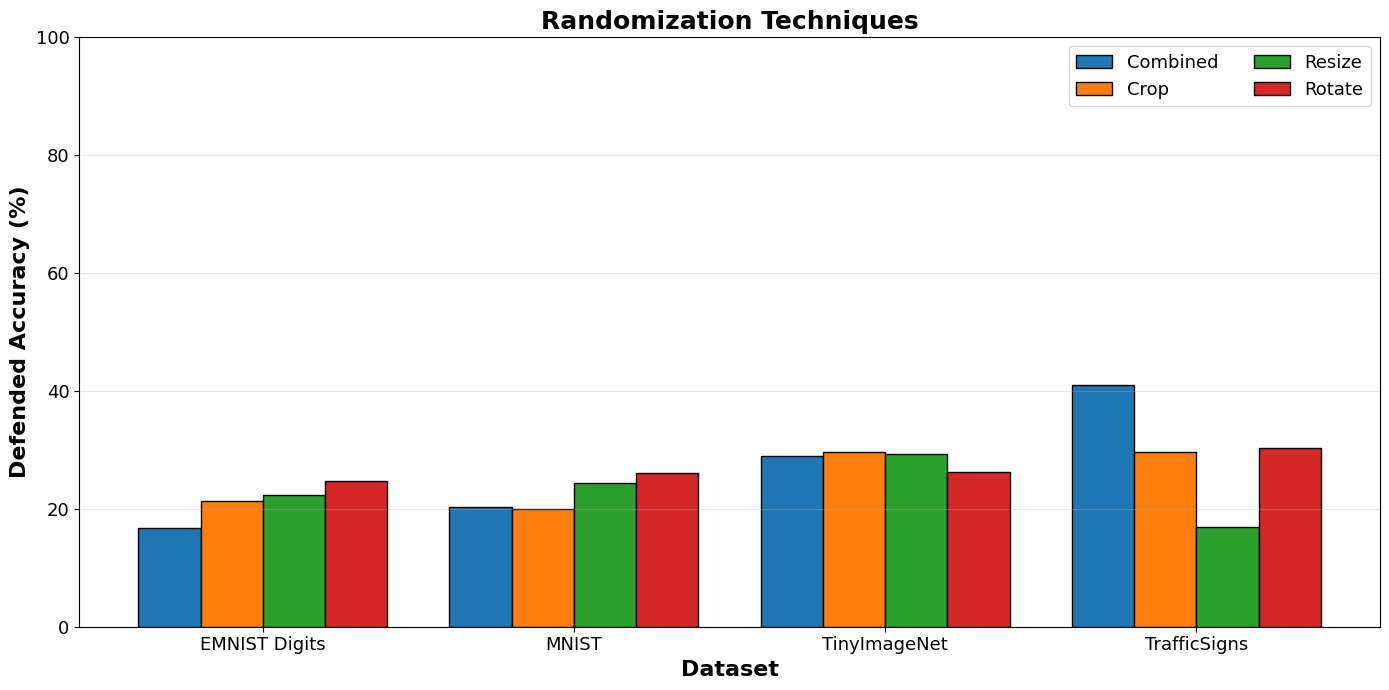

Chart 4: Attack Comparison


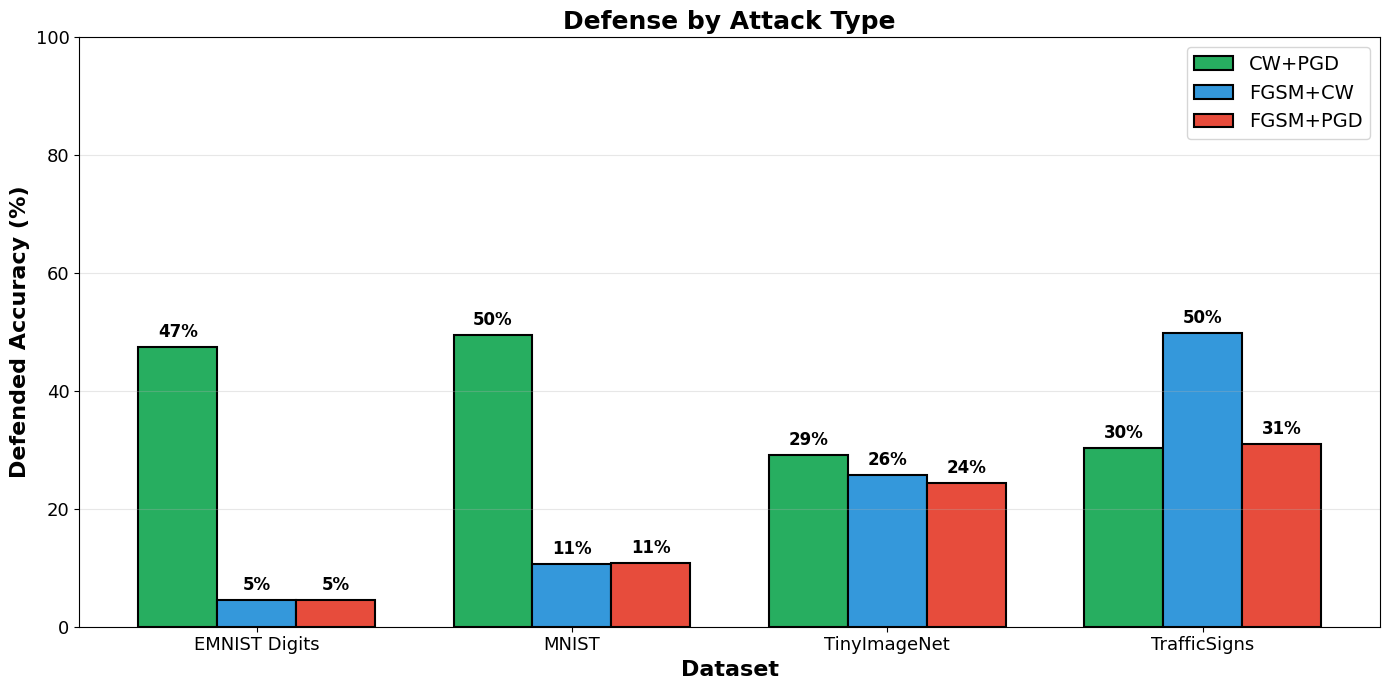

Chart 5: Accuracy Progression


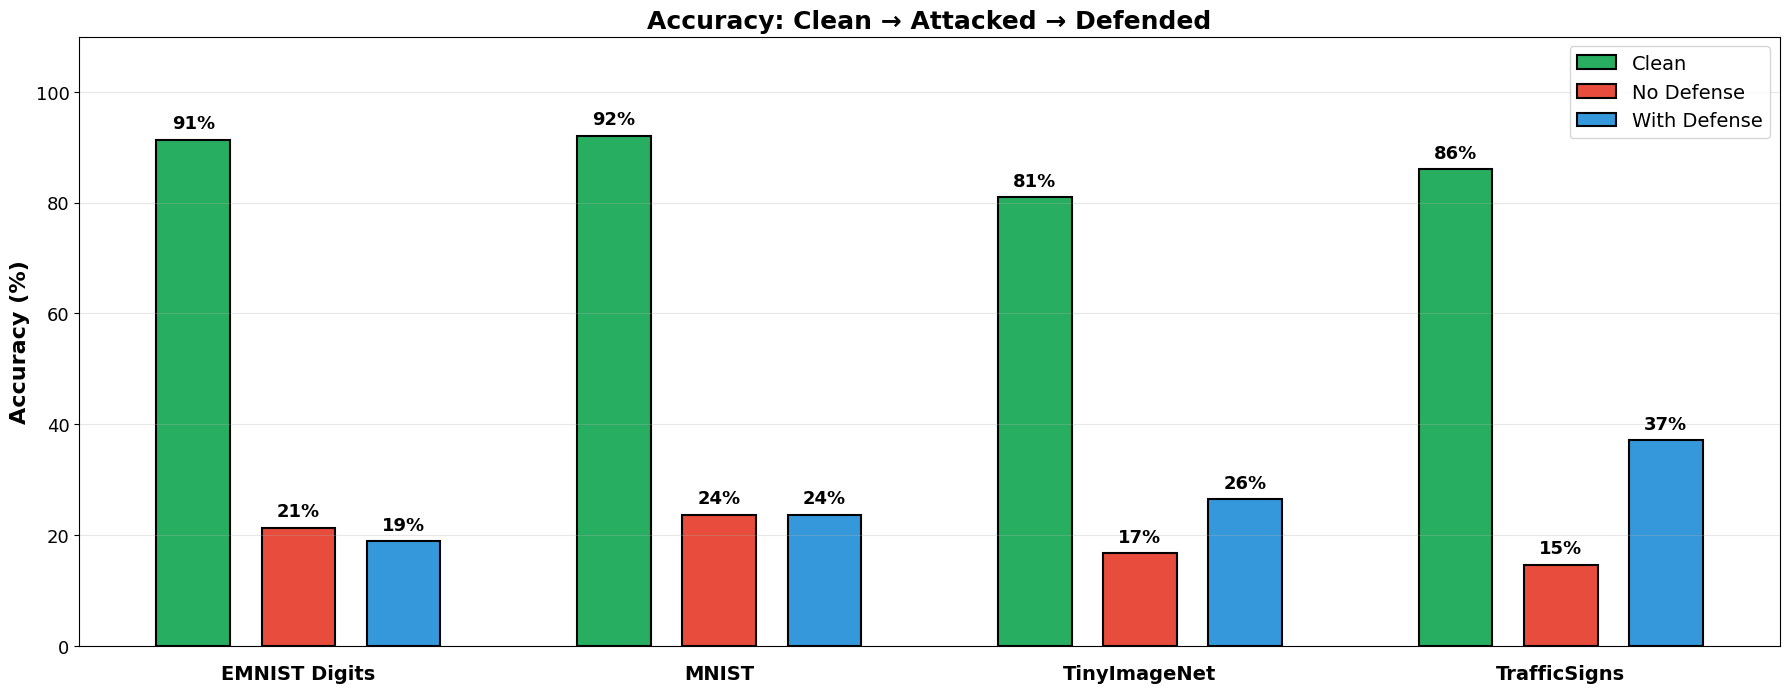

Chart 6: Recovery Rates


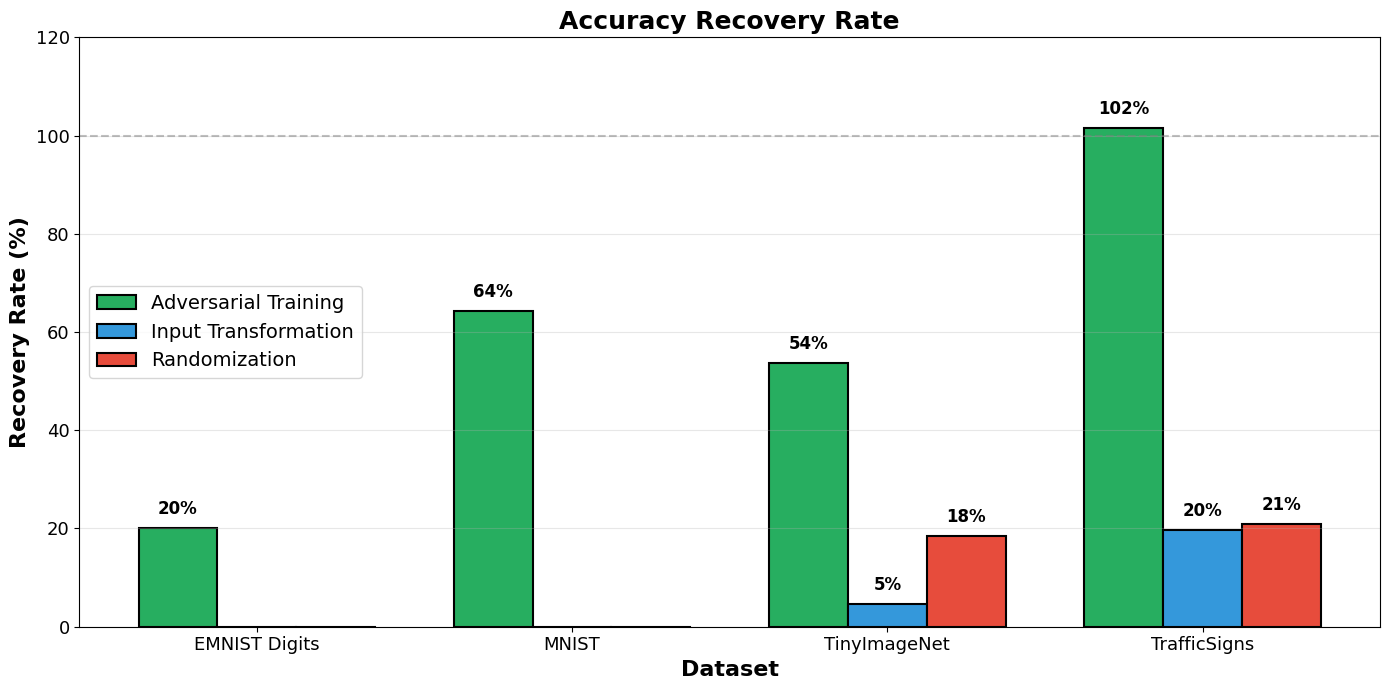

Chart 7: Attack Success


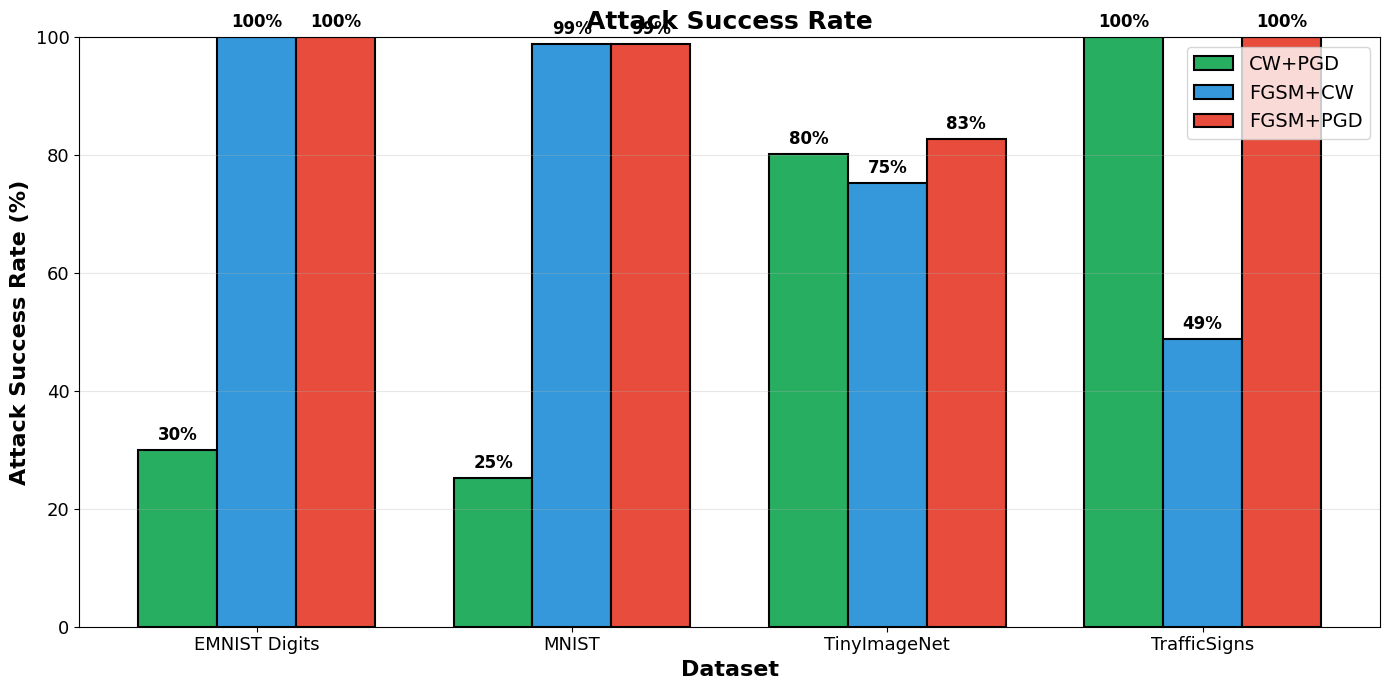

Chart 8: Best Techniques (2-column)


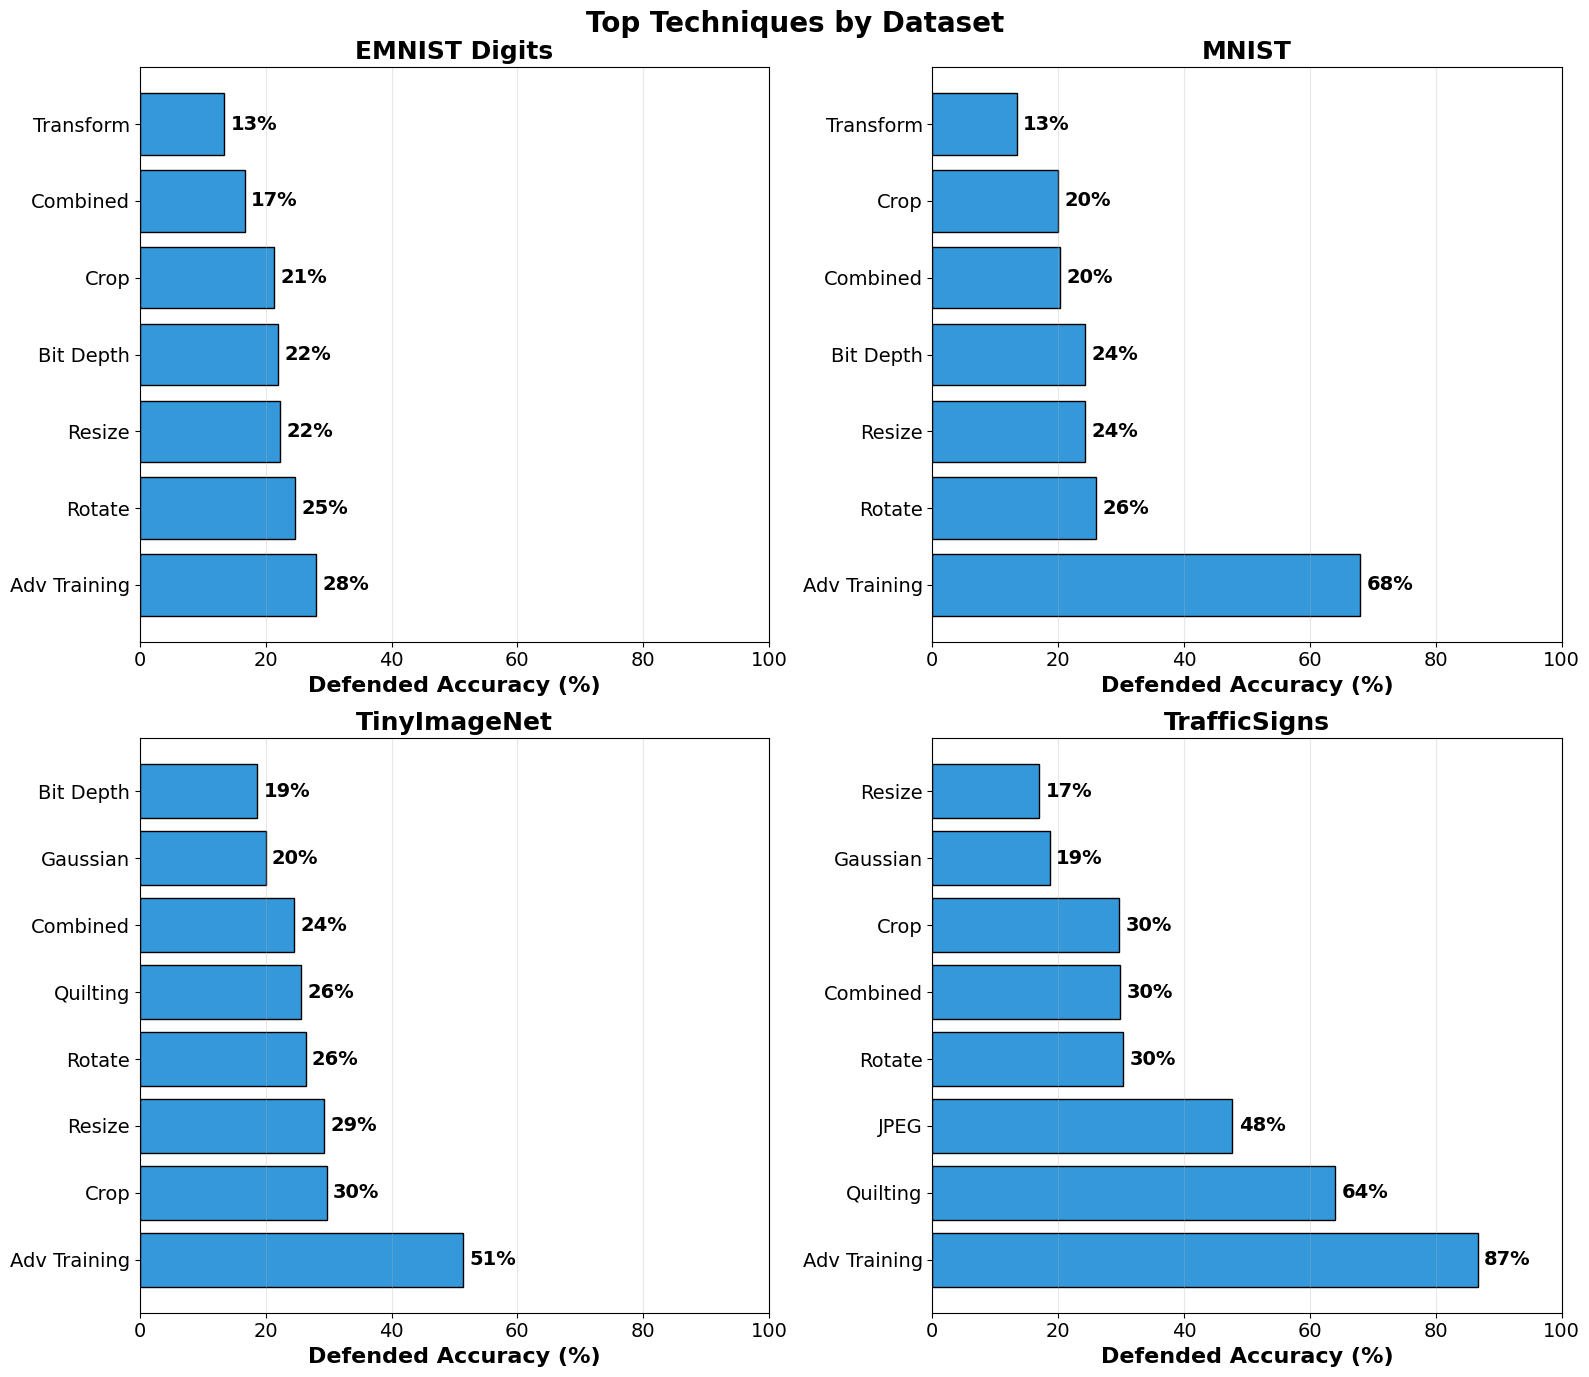

Chart 9: Adversarial Training


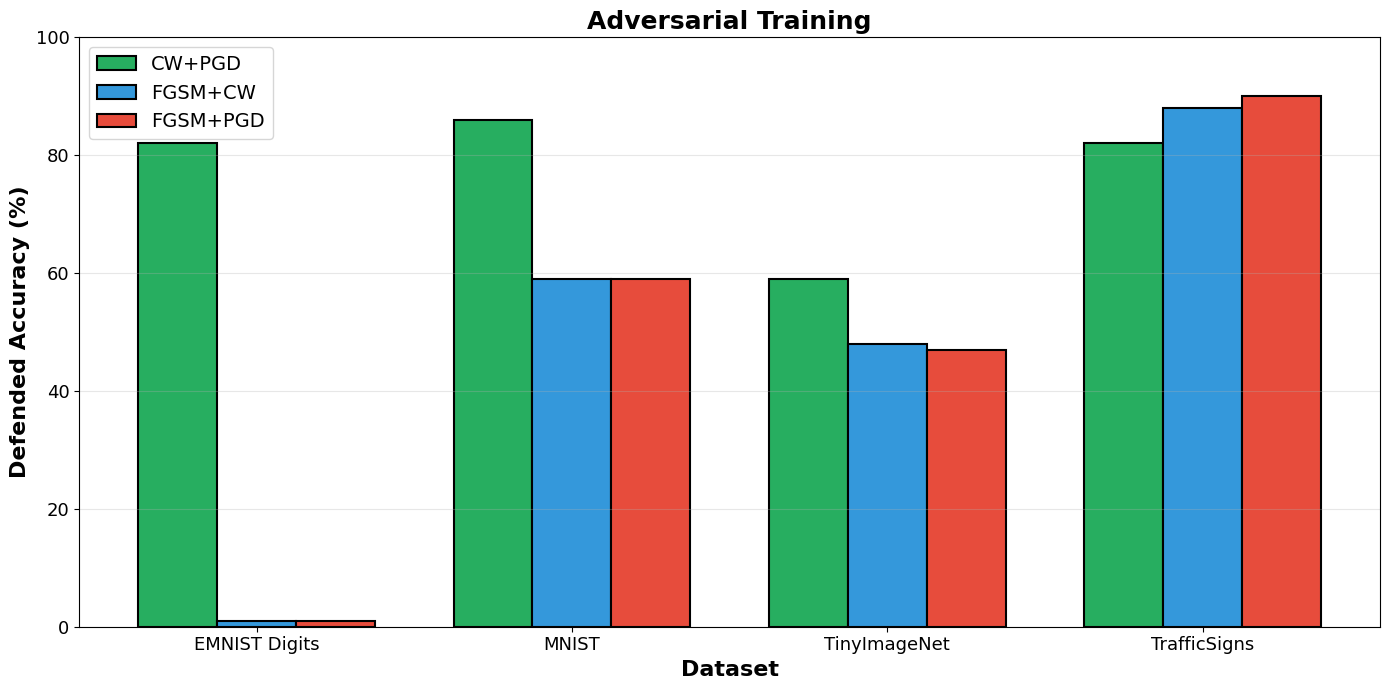

Chart 10: Robustness


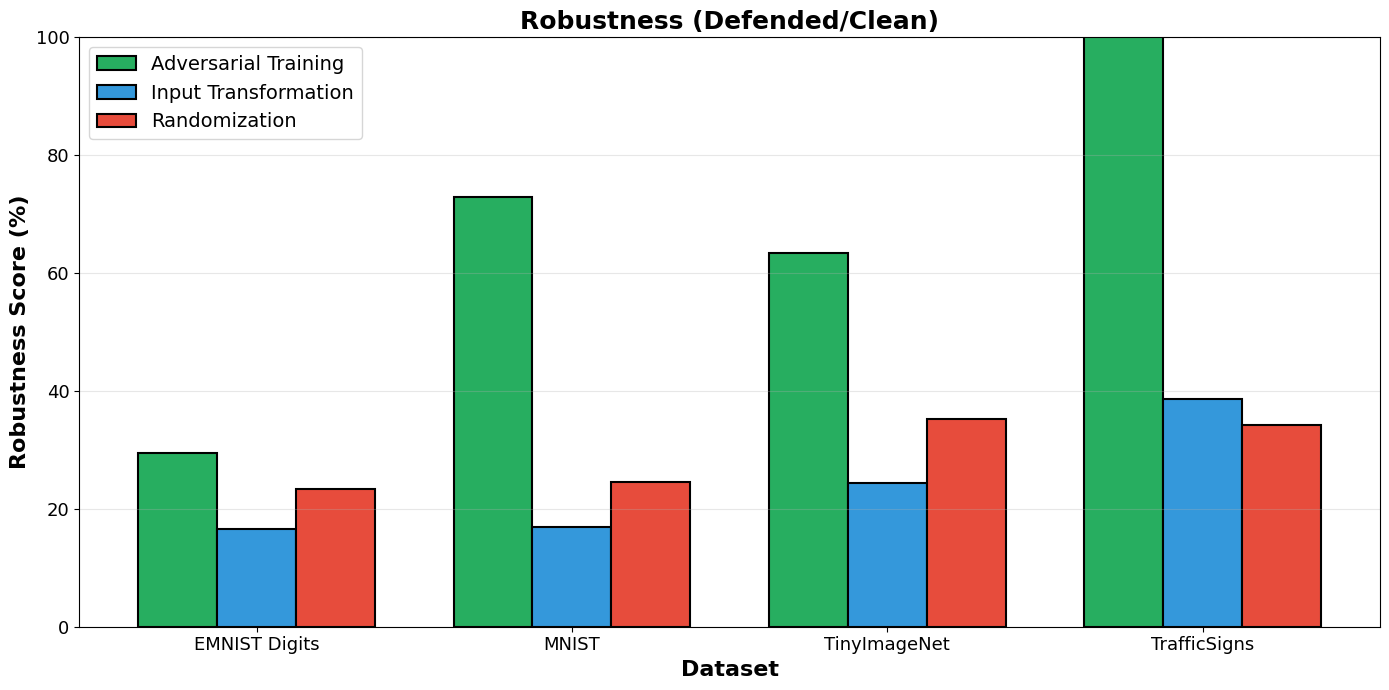

Chart 11: Heatmap (2-column)


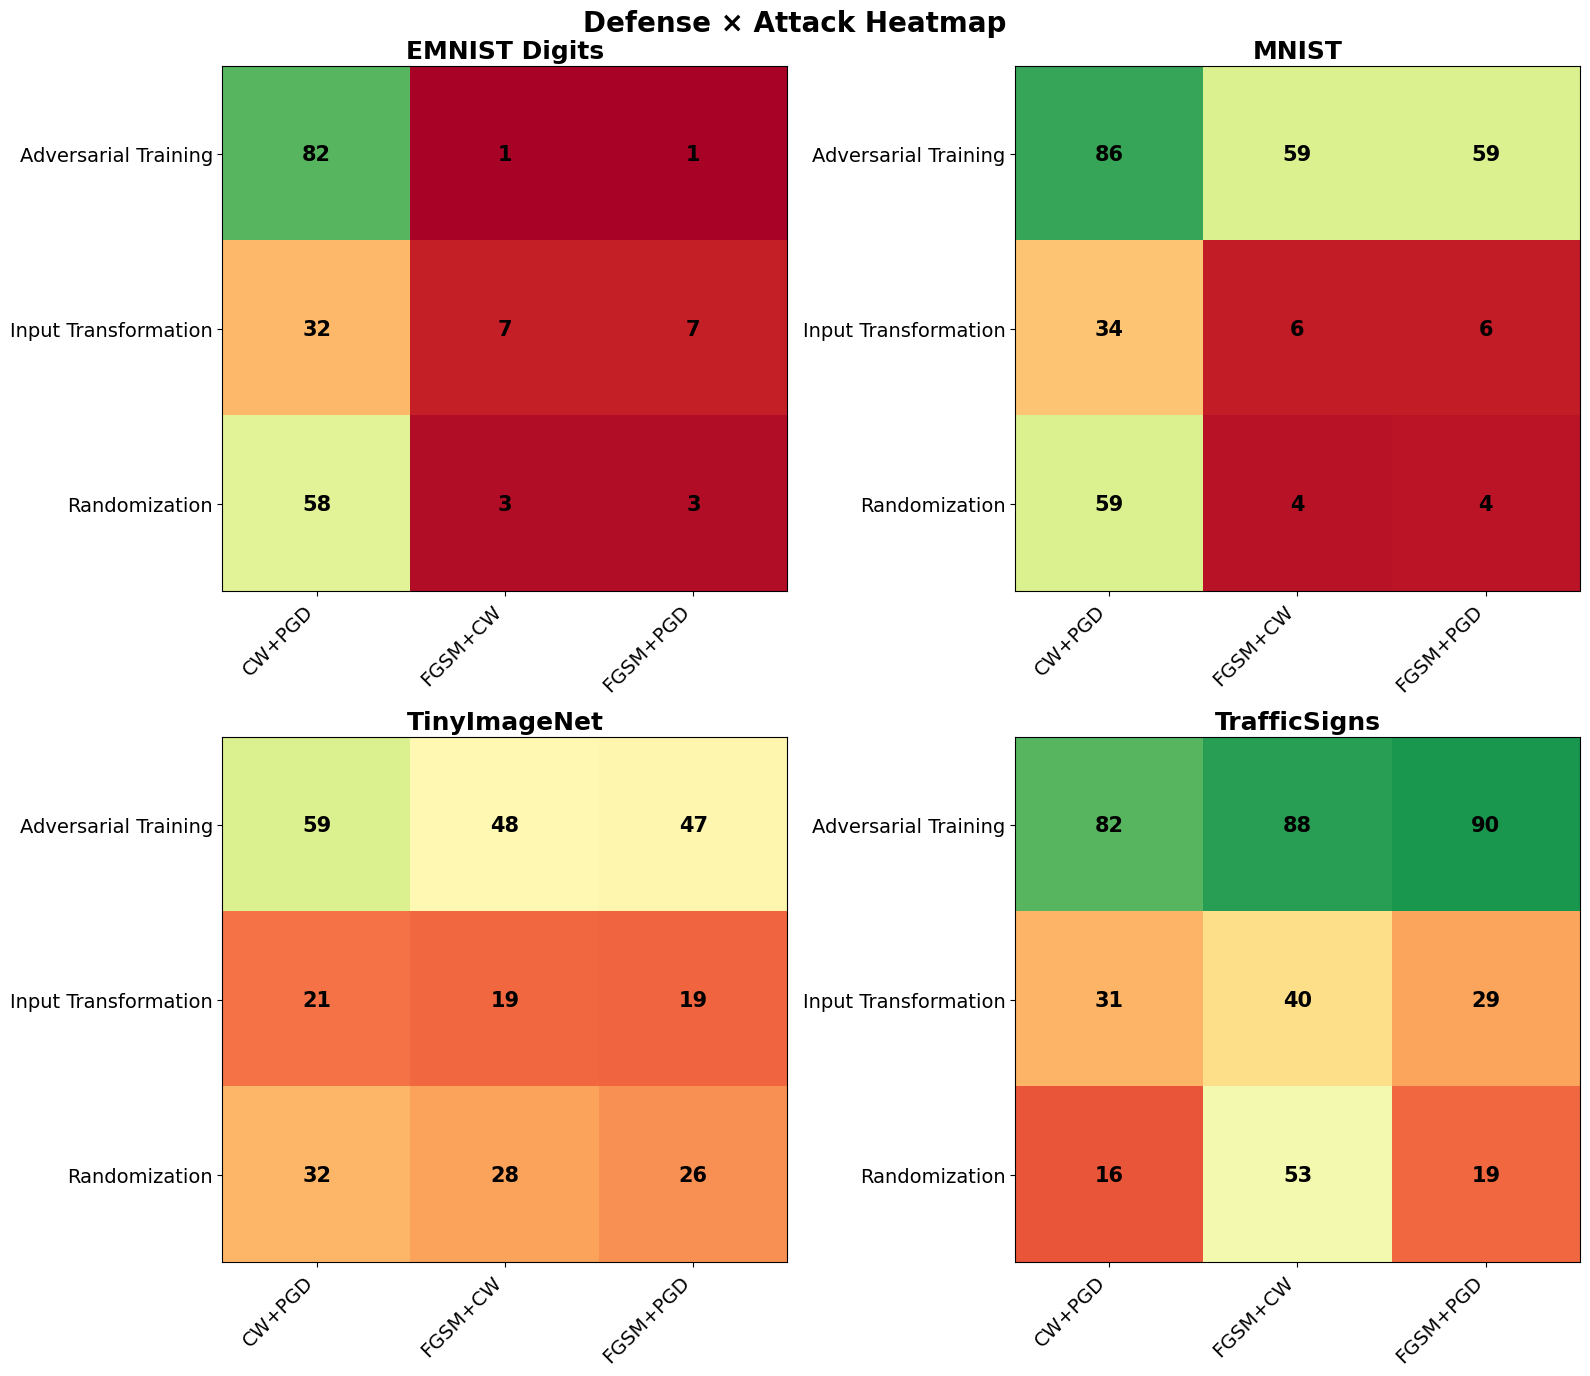

Chart 12: Summary


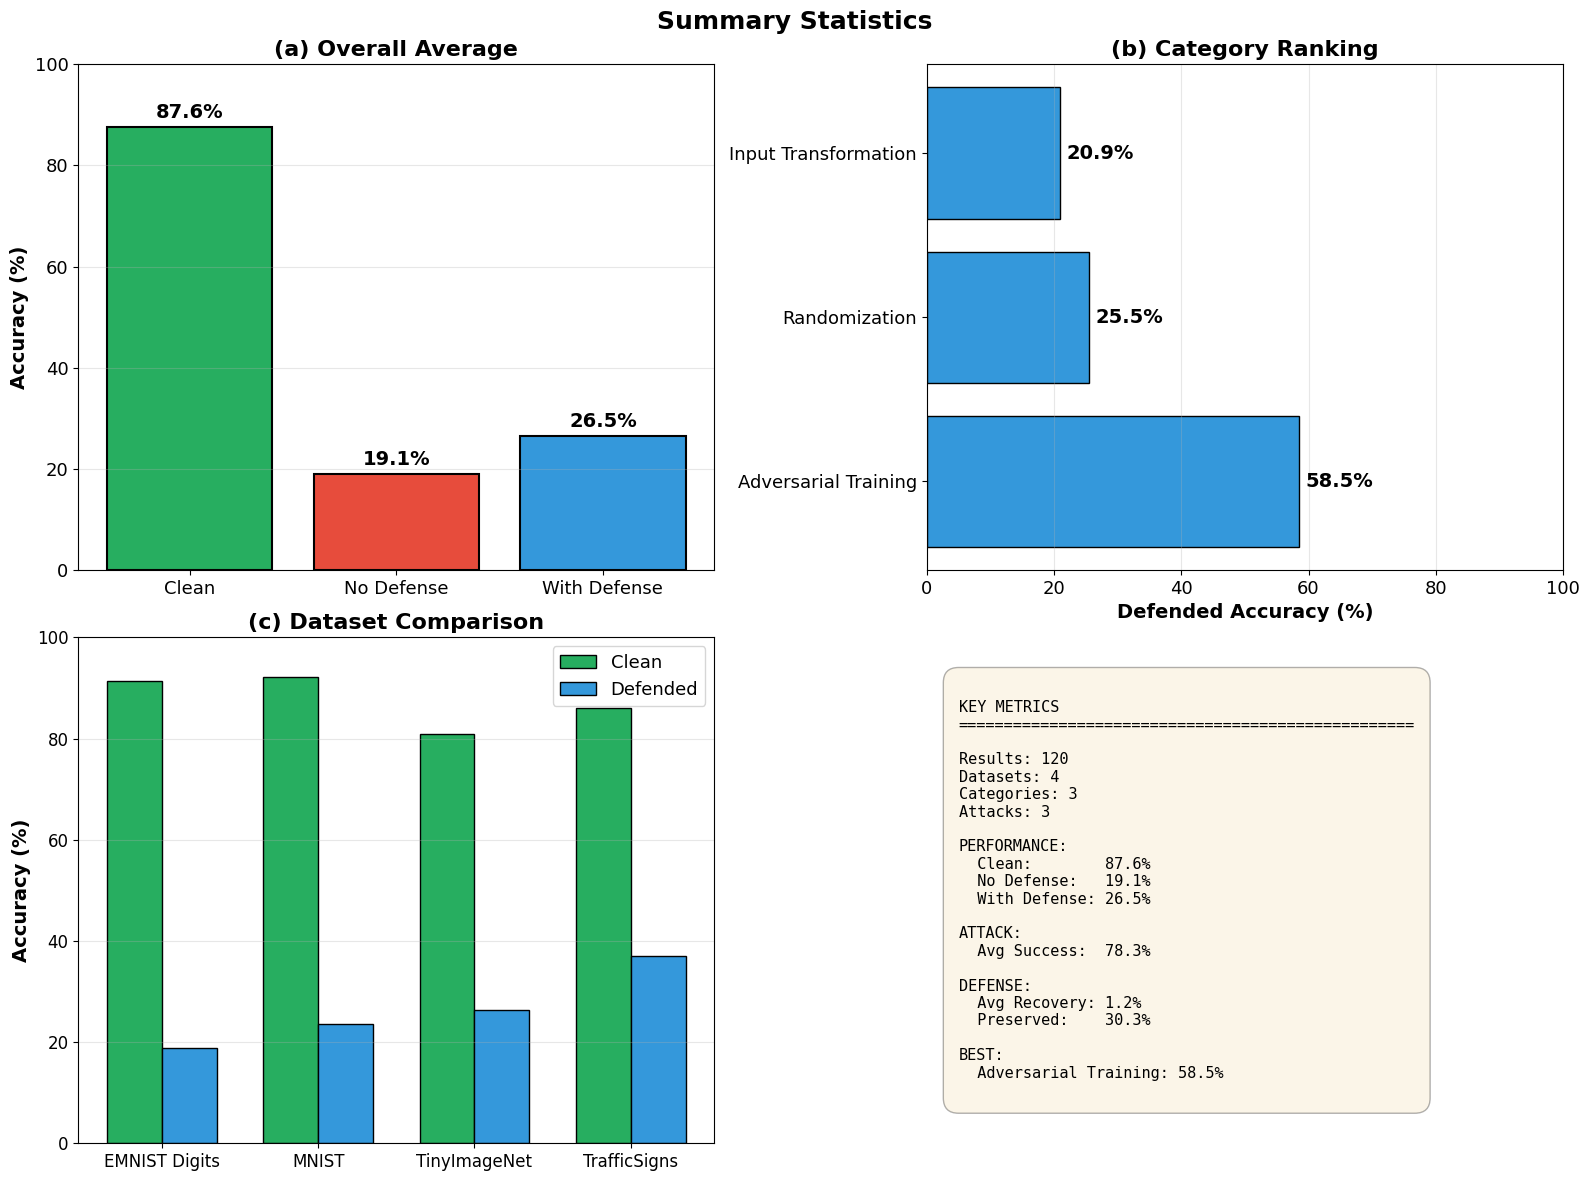

Chart 13: Radar Charts - Defense Category Performance (2-column)


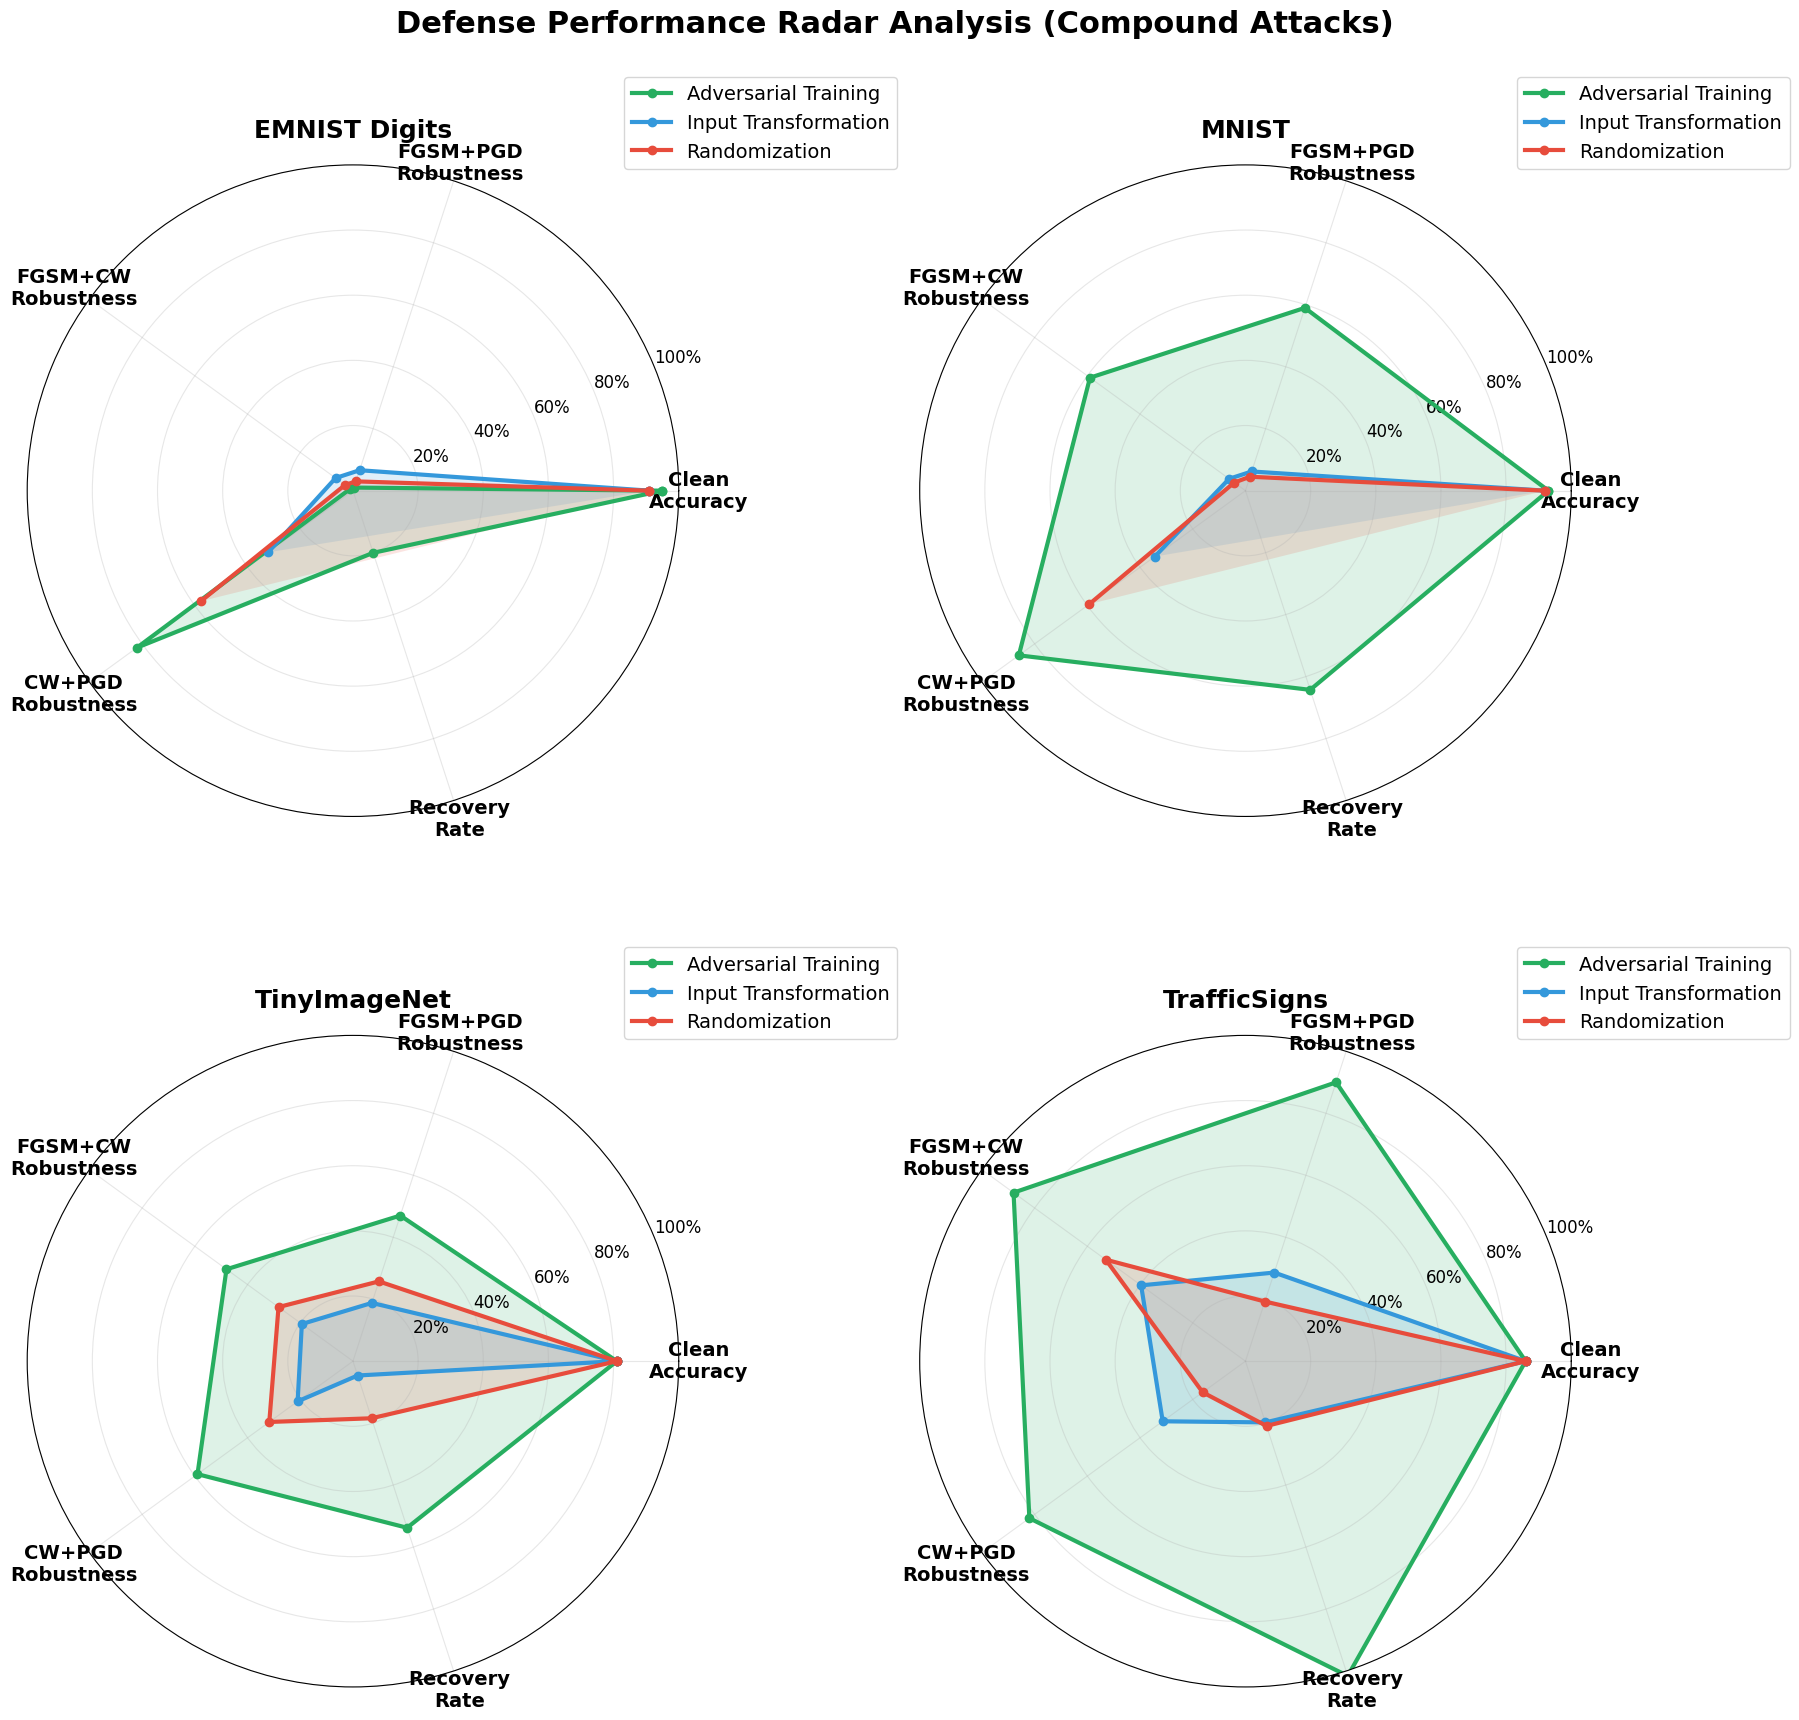

Chart 14: Comparative Radar - Best vs Average Defense (COMPOUND ATTACKS)


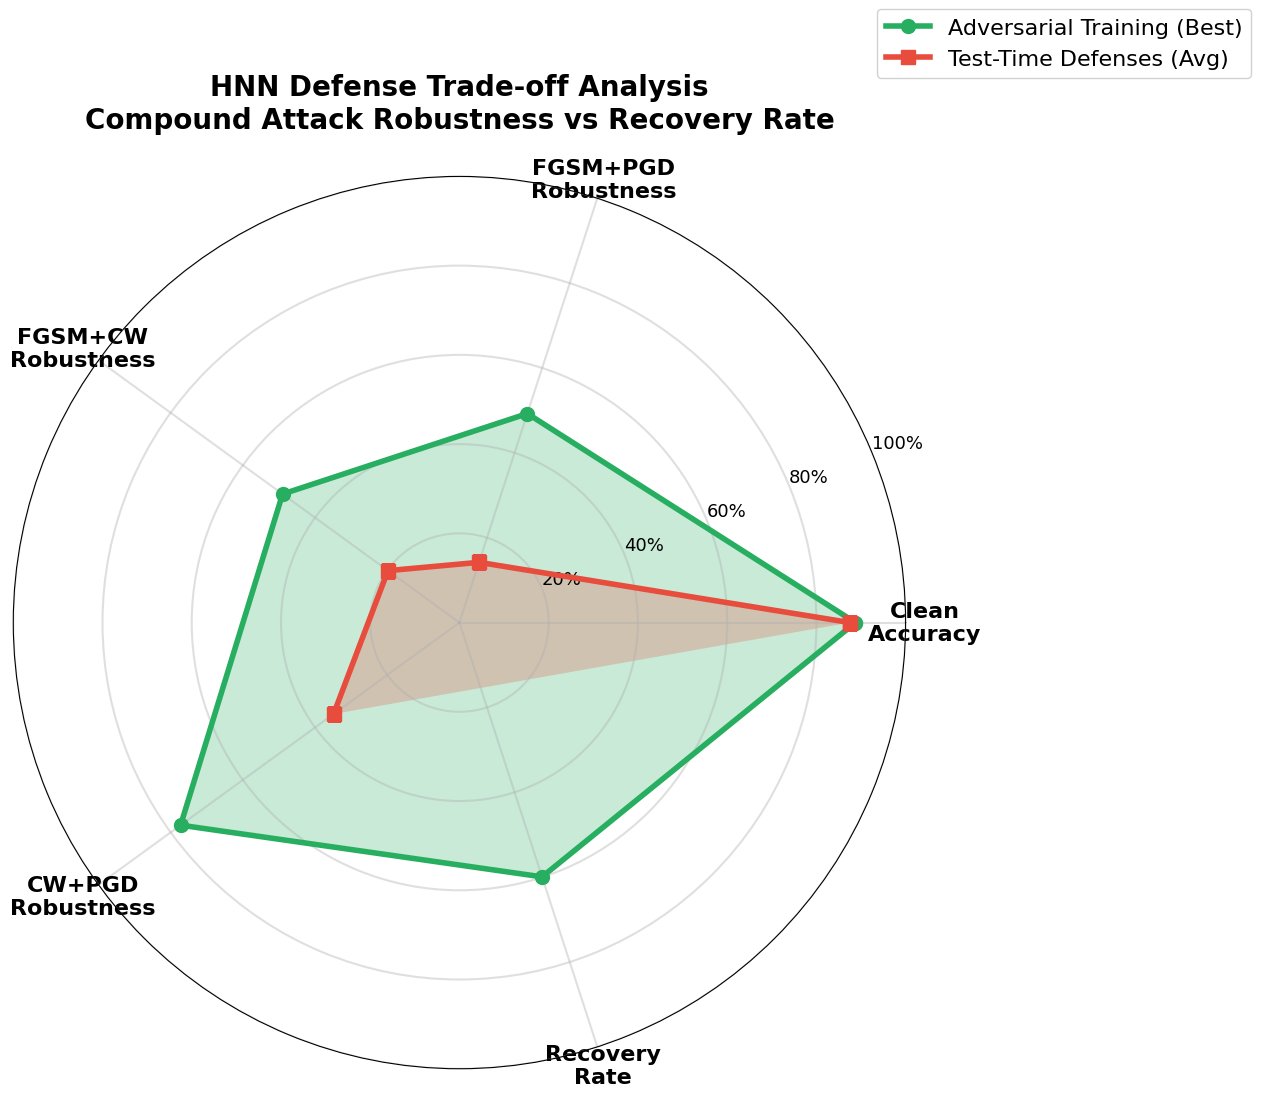


COMPLETE!

Saved to: /content/drive/MyDrive/results/IEEE_charts/
Datasets: EMNIST Digits, MNIST, TinyImageNet, TrafficSigns
Results: 120
Compound Attacks: CW+PGD, FGSM+CW, FGSM+PGD
Charts generated: 14 (including 2 radar charts with COMPOUND attacks)



In [3]:
import matplotlib.pyplot as plt
import numpy as np
import re
import os
from glob import glob

print("\n" + "="*80)
print("CHARTS - COMPOUND ATTACKS VERSION")
print("="*80 + "\n")

# Mount Google Drive
try:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        print("Mounting Google Drive...")
        drive.mount('/content/drive')
        print("✓ Mounted\n")
except:
    pass

# Find result files
result_paths = [
    '/content/drive/MyDrive/results/',
    '/content/drive/My Drive/results/',
]

result_files = []
for path in result_paths:
    if os.path.exists(path):
        files = glob(f'{path}*.txt')
        if files:
            result_files = files
            print(f"✓ Found {len(files)} result files\n")
            break

if not result_files:
    print("ERROR: No result files found!")
    exit(1)

# EXTRACT DATA - FIXED DATASET DETECTION
def extract_data(filepath):
    try:
        with open(filepath, 'r') as f:
            content = f.read()
    except:
        return None

    if '| Accuracy |' not in content:
        return None

    match = re.search(r'\|\s*Accuracy\s*\|\s*(\d+)%\s*\|\s*(\d+)%\s*\|\s*(\d+)%', content)
    if not match:
        return None

    clean, no_def, with_def = int(match.group(1)), int(match.group(2)), int(match.group(3))
    filename = os.path.basename(filepath).lower()

    # Dataset - FIXED TO DETECT MNI_ AND EMN_
    if 'tinyimagenet' in filename or 'tiny' in filename:
        dataset = 'TinyImageNet'
    elif 'trafficsigns' in filename or 'tra_' in filename:
        dataset = 'TrafficSigns'
    elif 'emnist' in filename or 'emn_' in filename:
        dataset = 'EMNIST Digits'
    elif 'mnist' in filename or 'mni_' in filename:
        dataset = 'MNIST'
    else:
        return None

    # Defense
    if 'adversarial_training' in filename:
        defense_cat, defense_tech = 'Adversarial Training', 'Adv Training'
    elif 'input_transformation' in filename:
        defense_cat = 'Input Transformation'
        if 'quilting' in filename:
            defense_tech = 'Quilting'
        elif 'bit' in filename:
            defense_tech = 'Bit Depth'
        elif 'jpeg' in filename:
            defense_tech = 'JPEG'
        elif 'gaussian' in filename or 'noise' in filename:
            defense_tech = 'Gaussian'
        elif 'combined' in filename:
            defense_tech = 'Combined'
        else:
            defense_tech = 'Transform'
    elif 'randomization' in filename:
        defense_cat = 'Randomization'
        if 'crop' in filename:
            defense_tech = 'Crop'
        elif 'resiz' in filename:
            defense_tech = 'Resize'
        elif 'rotat' in filename:
            defense_tech = 'Rotate'
        elif 'combined' in filename:
            defense_tech = 'Combined'
        else:
            defense_tech = 'Random'
    else:
        return None

    # Attack
    if 'fgsm_pgd' in filename:
        attack = 'FGSM+PGD'
    elif 'fgsm_cw' in filename:
        attack = 'FGSM+CW'
    elif 'cw_pgd' in filename:
        attack = 'CW+PGD'
    else:
        attack = 'Unknown'

    return {'dataset': dataset, 'defense_cat': defense_cat, 'defense_tech': defense_tech,
            'attack': attack, 'clean': clean, 'no_def': no_def, 'with_def': with_def}

# Extract all data
data = [d for d in (extract_data(f) for f in result_files) if d]
print(f"✓ Extracted: {len(data)} results")

if not data:
    print("ERROR: No valid data!")
    exit(1)

datasets = sorted(set(d['dataset'] for d in data))
categories = sorted(set(d['defense_cat'] for d in data))
attacks = sorted(set(d['attack'] for d in data if d['attack'] != 'Unknown'))

print(f"✓ Datasets: {datasets}")
print(f"✓ Categories: {categories}")
print(f"✓ Attacks: {attacks}\n")

# Save to Google Drive
save_dir = '/content/drive/MyDrive/results/IEEE_charts/'
os.makedirs(save_dir, exist_ok=True)
print(f"✓ Saving to: {save_dir}\n")

colors = ['#27ae60', '#3498db', '#e74c3c']

# ==================== CHART 1 ====================
print("Chart 1: Category Overview")
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(datasets))
width = 0.25
for i, cat in enumerate(categories):
    accs = [np.mean([d['with_def'] for d in data if d['dataset']==ds and d['defense_cat']==cat] or [0]) for ds in datasets]
    bars = ax.bar(x + (i-1)*width, accs, width, label=cat, color=colors[i % 3], edgecolor='black', linewidth=1.5)
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.0f}%',
                   ha='center', va='bottom', fontsize=12, weight='bold')
ax.set_xlabel('Dataset', fontsize=16, weight='bold')
ax.set_ylabel('Defended Accuracy (%)', fontsize=16, weight='bold')
ax.set_title('Defense Category Effectiveness', fontsize=18, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=14)
ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=13)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}chart01_category.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ==================== CHART 2 ====================
print("Chart 2: Input Transformation")
fig, ax = plt.subplots(figsize=(14, 7))
input_data = [d for d in data if d['defense_cat'] == 'Input Transformation']
if input_data:
    techs = sorted(set(d['defense_tech'] for d in input_data))
    x = np.arange(len(datasets))
    width = 0.8 / max(len(techs), 1)
    for i, tech in enumerate(techs):
        accs = [np.mean([d['with_def'] for d in input_data if d['dataset']==ds and d['defense_tech']==tech] or [0]) for ds in datasets]
        ax.bar(x + (i - len(techs)/2 + 0.5)*width, accs, width, label=tech, edgecolor='black')
    ax.legend(ncol=2, fontsize=13)
ax.set_xlabel('Dataset', fontsize=16, weight='bold')
ax.set_ylabel('Defended Accuracy (%)', fontsize=16, weight='bold')
ax.set_title('Input Transformation Techniques', fontsize=18, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=13)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}chart02_input.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ==================== CHART 3 ====================
print("Chart 3: Randomization")
fig, ax = plt.subplots(figsize=(14, 7))
rand_data = [d for d in data if d['defense_cat'] == 'Randomization']
if rand_data:
    techs = sorted(set(d['defense_tech'] for d in rand_data))
    x = np.arange(len(datasets))
    width = 0.8 / max(len(techs), 1)
    for i, tech in enumerate(techs):
        accs = [np.mean([d['with_def'] for d in rand_data if d['dataset']==ds and d['defense_tech']==tech] or [0]) for ds in datasets]
        ax.bar(x + (i - len(techs)/2 + 0.5)*width, accs, width, label=tech, edgecolor='black')
    ax.legend(ncol=2, fontsize=13)
ax.set_xlabel('Dataset', fontsize=16, weight='bold')
ax.set_ylabel('Defended Accuracy (%)', fontsize=16, weight='bold')
ax.set_title('Randomization Techniques', fontsize=18, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=13)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}chart03_random.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ==================== CHART 4 ====================
print("Chart 4: Attack Comparison")
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(datasets))
width = 0.25
for i, att in enumerate(attacks):
    accs = [np.mean([d['with_def'] for d in data if d['dataset']==ds and d['attack']==att] or [0]) for ds in datasets]
    bars = ax.bar(x + (i-1)*width, accs, width, label=att, color=colors[i % 3], edgecolor='black', linewidth=1.5)
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.0f}%',
                   ha='center', va='bottom', fontsize=12, weight='bold')
ax.set_xlabel('Dataset', fontsize=16, weight='bold')
ax.set_ylabel('Defended Accuracy (%)', fontsize=16, weight='bold')
ax.set_title('Defense by Attack Type', fontsize=18, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=14)
ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=13)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}chart04_attacks.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ==================== CHART 5 ====================
print("Chart 5: Accuracy Progression")
fig, ax = plt.subplots(figsize=(18, 7))
x_pos = 0
for ds in datasets:
    ds_data = [d for d in data if d['dataset']==ds]
    clean = np.mean([d['clean'] for d in ds_data])
    nodef = np.mean([d['no_def'] for d in ds_data])
    withdef = np.mean([d['with_def'] for d in ds_data])
    ax.bar(x_pos, clean, 0.7, color='#27ae60', edgecolor='black', linewidth=1.5, label='Clean' if x_pos==0 else '')
    ax.bar(x_pos+1, nodef, 0.7, color='#e74c3c', edgecolor='black', linewidth=1.5, label='No Defense' if x_pos==0 else '')
    ax.bar(x_pos+2, withdef, 0.7, color='#3498db', edgecolor='black', linewidth=1.5, label='With Defense' if x_pos==0 else '')
    ax.text(x_pos, clean+2, f'{clean:.0f}%', ha='center', fontsize=13, weight='bold')
    ax.text(x_pos+1, nodef+2, f'{nodef:.0f}%', ha='center', fontsize=13, weight='bold')
    ax.text(x_pos+2, withdef+2, f'{withdef:.0f}%', ha='center', fontsize=13, weight='bold')
    ax.text(x_pos+1, -6, ds, ha='center', fontsize=14, weight='bold')
    x_pos += 4
ax.set_ylabel('Accuracy (%)', fontsize=16, weight='bold')
ax.set_title('Accuracy: Clean → Attacked → Defended', fontsize=18, weight='bold')
ax.set_ylim([0, 110])
ax.grid(axis='y', alpha=0.3)
ax.set_xticks([])
ax.legend(loc='upper right', fontsize=14)
ax.tick_params(axis='y', which='major', labelsize=13)
plt.tight_layout()
plt.savefig(f'{save_dir}chart05_progression.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ==================== CHART 6 ====================
print("Chart 6: Recovery Rates")
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(datasets))
width = 0.25
for i, cat in enumerate(categories):
    recoveries = []
    for ds in datasets:
        vals = [d for d in data if d['dataset']==ds and d['defense_cat']==cat]
        if vals:
            rates = [((d['with_def'] - d['no_def']) / (d['clean'] - d['no_def']) * 100) if d['clean'] > d['no_def'] else 0 for d in vals]
            recoveries.append(np.mean(rates))
        else:
            recoveries.append(0)
    bars = ax.bar(x + (i-1)*width, recoveries, width, label=cat, color=colors[i % 3], edgecolor='black', linewidth=1.5)
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{bar.get_height():.0f}%',
                   ha='center', va='bottom', fontsize=12, weight='bold')
ax.set_xlabel('Dataset', fontsize=16, weight='bold')
ax.set_ylabel('Recovery Rate (%)', fontsize=16, weight='bold')
ax.set_title('Accuracy Recovery Rate', fontsize=18, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=14)
ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=13)
ax.set_ylim([0, 120])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{save_dir}chart06_recovery.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ==================== CHART 7 ====================
print("Chart 7: Attack Success")
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(datasets))
width = 0.25
for i, att in enumerate(attacks):
    success = []
    for ds in datasets:
        vals = [d for d in data if d['dataset']==ds and d['attack']==att]
        if vals:
            rates = [((d['clean'] - d['no_def']) / d['clean'] * 100) if d['clean'] > 0 else 0 for d in vals]
            success.append(np.mean(rates))
        else:
            success.append(0)
    bars = ax.bar(x + (i-1)*width, success, width, label=att, color=colors[i % 3], edgecolor='black', linewidth=1.5)
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.0f}%',
                   ha='center', va='bottom', fontsize=12, weight='bold')
ax.set_xlabel('Dataset', fontsize=16, weight='bold')
ax.set_ylabel('Attack Success Rate (%)', fontsize=16, weight='bold')
ax.set_title('Attack Success Rate', fontsize=18, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=14)
ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=13)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}chart07_attack_success.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ==================== CHART 8: 2-COLUMN LAYOUT ====================
print("Chart 8: Best Techniques (2-column)")
if datasets:
    # Calculate rows needed (2 columns)
    n_rows = (len(datasets) + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 7*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for idx, ds in enumerate(datasets):
        row = idx // 2
        col = idx % 2
        ax = axes[row, col]

        ds_data = [d for d in data if d['dataset']==ds]
        tech_accs = {}
        for d in ds_data:
            tech = d['defense_tech']
            tech_accs.setdefault(tech, []).append(d['with_def'])
        tech_avg = sorted([(k, np.mean(v)) for k, v in tech_accs.items()], key=lambda x: x[1], reverse=True)[:8]
        if tech_avg:
            techs, accs = zip(*tech_avg)
            bars = ax.barh(range(len(techs)), accs, color='#3498db', edgecolor='black')
            for i, bar in enumerate(bars):
                ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.0f}%',
                       ha='left', va='center', fontsize=14, weight='bold')
            ax.set_yticks(range(len(techs)))
            ax.set_yticklabels(techs, fontsize=14)
        ax.set_xlabel('Defended Accuracy (%)', fontsize=16, weight='bold')
        ax.set_title(f'{ds}', fontsize=18, weight='bold')
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.set_xlim([0, 100])
        ax.grid(axis='x', alpha=0.3)

    # Hide unused subplots
    for idx in range(len(datasets), n_rows * 2):
        row = idx // 2
        col = idx % 2
        axes[row, col].set_visible(False)

    plt.suptitle('Top Techniques by Dataset', fontsize=20, weight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}chart08_best.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# ==================== CHART 9 ====================
print("Chart 9: Adversarial Training")
adv_data = [d for d in data if d['defense_cat'] == 'Adversarial Training']
if adv_data:
    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(datasets))
    width = 0.25
    for i, att in enumerate(attacks):
        accs = [np.mean([d['with_def'] for d in adv_data if d['dataset']==ds and d['attack']==att] or [0]) for ds in datasets]
        ax.bar(x + (i-1)*width, accs, width, label=att, color=colors[i % 3], edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Dataset', fontsize=16, weight='bold')
    ax.set_ylabel('Defended Accuracy (%)', fontsize=16, weight='bold')
    ax.set_title('Adversarial Training', fontsize=18, weight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=14)
    ax.legend(fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.set_ylim([0, 100])
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{save_dir}chart09_advtrain.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# ==================== CHART 10 ====================
print("Chart 10: Robustness")
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(datasets))
width = 0.25
for i, cat in enumerate(categories):
    robustness = []
    for ds in datasets:
        vals = [d for d in data if d['dataset']==ds and d['defense_cat']==cat]
        if vals:
            scores = [(d['with_def'] / d['clean'] * 100) if d['clean'] > 0 else 0 for d in vals]
            robustness.append(np.mean(scores))
        else:
            robustness.append(0)
    ax.bar(x + (i-1)*width, robustness, width, label=cat, color=colors[i % 3], edgecolor='black', linewidth=1.5)
ax.set_xlabel('Dataset', fontsize=16, weight='bold')
ax.set_ylabel('Robustness Score (%)', fontsize=16, weight='bold')
ax.set_title('Robustness (Defended/Clean)', fontsize=18, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=14)
ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=13)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{save_dir}chart10_robustness.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ==================== CHART 11: HEATMAP 2-COLUMN ====================
print("Chart 11: Heatmap (2-column)")
if datasets:
    n_rows = (len(datasets) + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 7*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    for idx, ds in enumerate(datasets):
        row = idx // 2
        col = idx % 2
        ax = axes[row, col]

        matrix = np.zeros((len(categories), len(attacks)))
        for i, cat in enumerate(categories):
            for j, att in enumerate(attacks):
                vals = [d['with_def'] for d in data if d['dataset']==ds and d['defense_cat']==cat and d['attack']==att]
                matrix[i, j] = np.mean(vals) if vals else 0
        im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
        ax.set_xticks(range(len(attacks)))
        ax.set_yticks(range(len(categories)))
        ax.set_xticklabels(attacks, rotation=45, ha='right', fontsize=14)
        ax.set_yticklabels(categories, fontsize=14)
        for i in range(len(categories)):
            for j in range(len(attacks)):
                ax.text(j, i, f'{matrix[i, j]:.0f}', ha="center", va="center", color="black", fontsize=15, weight='bold')
        ax.set_title(f'{ds}', fontsize=18, weight='bold')
        ax.tick_params(axis='both', which='major', labelsize=14)

    # Hide unused subplots
    for idx in range(len(datasets), n_rows * 2):
        row = idx // 2
        col = idx % 2
        axes[row, col].set_visible(False)

    plt.suptitle('Defense × Attack Heatmap', fontsize=20, weight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}chart11_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# ==================== CHART 12 ====================
print("Chart 12: Summary")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
overall_clean = np.mean([d['clean'] for d in data])
overall_nodef = np.mean([d['no_def'] for d in data])
overall_withdef = np.mean([d['with_def'] for d in data])
bars = axes[0, 0].bar(['Clean', 'No Defense', 'With Defense'], [overall_clean, overall_nodef, overall_withdef],
                      color=['#27ae60', '#e74c3c', '#3498db'], edgecolor='black', linewidth=1.5)
for bar in bars:
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.1f}%',
                   ha='center', va='bottom', fontsize=14, weight='bold')
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=14, weight='bold')
axes[0, 0].set_title('(a) Overall Average', fontsize=16, weight='bold')
axes[0, 0].tick_params(axis='both', which='major', labelsize=13)
axes[0, 0].set_ylim([0, 100])
axes[0, 0].grid(axis='y', alpha=0.3)

cat_avgs = sorted([(cat, np.mean([d['with_def'] for d in data if d['defense_cat']==cat])) for cat in categories], key=lambda x: x[1], reverse=True)
if cat_avgs:
    cats, vals = zip(*cat_avgs)
    bars = axes[0, 1].barh(range(len(cats)), vals, color='#3498db', edgecolor='black')
    for i, bar in enumerate(bars):
        axes[0, 1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%',
                       ha='left', va='center', fontsize=14, weight='bold')
    axes[0, 1].set_yticks(range(len(cats)))
    axes[0, 1].set_yticklabels(cats, fontsize=13)
axes[0, 1].set_xlabel('Defended Accuracy (%)', fontsize=14, weight='bold')
axes[0, 1].set_title('(b) Category Ranking', fontsize=16, weight='bold')
axes[0, 1].tick_params(axis='both', which='major', labelsize=13)
axes[0, 1].set_xlim([0, 100])
axes[0, 1].grid(axis='x', alpha=0.3)

ds_stats = [(ds, np.mean([d['clean'] for d in data if d['dataset']==ds]), np.mean([d['with_def'] for d in data if d['dataset']==ds])) for ds in datasets]
if ds_stats:
    ds_names, ds_clean, ds_defended = zip(*ds_stats)
    x_ds = np.arange(len(ds_names))
    w = 0.35
    axes[1, 0].bar(x_ds - w/2, ds_clean, w, label='Clean', color='#27ae60', edgecolor='black')
    axes[1, 0].bar(x_ds + w/2, ds_defended, w, label='Defended', color='#3498db', edgecolor='black')
    axes[1, 0].set_xticks(x_ds)
    axes[1, 0].set_xticklabels(ds_names, fontsize=12)
    axes[1, 0].legend(fontsize=13)
axes[1, 0].set_ylabel('Accuracy (%)', fontsize=14, weight='bold')
axes[1, 0].set_title('(c) Dataset Comparison', fontsize=16, weight='bold')
axes[1, 0].tick_params(axis='both', which='major', labelsize=12)
axes[1, 0].set_ylim([0, 100])
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].axis('off')
recovery_rates = [((d['with_def'] - d['no_def']) / (d['clean'] - d['no_def']) * 100) if d['clean'] > d['no_def'] else 0 for d in data]
attack_success = [((d['clean'] - d['no_def']) / d['clean'] * 100) if d['clean'] > 0 else 0 for d in data]
summary = f"""
KEY METRICS
{'='*50}

Results: {len(data)}
Datasets: {len(datasets)}
Categories: {len(categories)}
Attacks: {len(attacks)}

PERFORMANCE:
  Clean:        {overall_clean:.1f}%
  No Defense:   {overall_nodef:.1f}%
  With Defense: {overall_withdef:.1f}%

ATTACK:
  Avg Success:  {np.mean(attack_success):.1f}%

DEFENSE:
  Avg Recovery: {np.mean(recovery_rates):.1f}%
  Preserved:    {(overall_withdef/overall_clean*100):.1f}%

BEST:
  {cat_avgs[0][0]}: {cat_avgs[0][1]:.1f}%
"""
axes[1, 1].text(0.05, 0.5, summary, fontsize=11, family='monospace', verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3, pad=1))
plt.suptitle('Summary Statistics', fontsize=18, weight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}chart12_summary.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ==================== CHART 13: RADAR CHARTS 2-COLUMN ====================
print("Chart 13: Radar Charts - Defense Category Performance (2-column)")

def compute_radar_metrics(dataset_name, defense_category):
    """Compute 5 radar metrics for a given dataset and defense - USING COMPOUND ATTACKS"""
    ds_data = [d for d in data if d['dataset']==dataset_name and d['defense_cat']==defense_category]

    if not ds_data:
        return None

    # Metric 1: Clean Accuracy
    clean_acc = np.mean([d['clean'] for d in ds_data])

    # Metric 2: FGSM+PGD Robustness (compound attack)
    fgsm_pgd_data = [d['with_def'] for d in ds_data if d['attack'] == 'FGSM+PGD']
    fgsm_pgd_robust = np.mean(fgsm_pgd_data) if fgsm_pgd_data else 0

    # Metric 3: FGSM+CW Robustness (compound attack)
    fgsm_cw_data = [d['with_def'] for d in ds_data if d['attack'] == 'FGSM+CW']
    fgsm_cw_robust = np.mean(fgsm_cw_data) if fgsm_cw_data else 0

    # Metric 4: CW+PGD Robustness (compound attack)
    cw_pgd_data = [d['with_def'] for d in ds_data if d['attack'] == 'CW+PGD']
    cw_pgd_robust = np.mean(cw_pgd_data) if cw_pgd_data else 0

    # Metric 5: Recovery Rate
    recovery_rates = [((d['with_def'] - d['no_def']) / (d['clean'] - d['no_def']) * 100)
                     if d['clean'] > d['no_def'] else 0 for d in ds_data]
    recovery = np.mean(recovery_rates)

    return [clean_acc, fgsm_pgd_robust, fgsm_cw_robust, cw_pgd_robust, recovery]

# Create radar chart for each dataset - 2 COLUMN LAYOUT
if datasets:
    n_rows = (len(datasets) + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(18, 9*n_rows), subplot_kw=dict(projection='polar'))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes_flat = axes.flatten()

    labels = ['Clean\nAccuracy', 'FGSM+PGD\nRobustness', 'FGSM+CW\nRobustness', 'CW+PGD\nRobustness', 'Recovery\nRate']
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle

    for idx, ds in enumerate(datasets):
        ax = axes_flat[idx]

        for cat_idx, cat in enumerate(categories):
            values = compute_radar_metrics(ds, cat)
            if values:
                values += values[:1]  # Complete the circle
                ax.plot(angles, values, 'o-', linewidth=3, label=cat, color=colors[cat_idx % 3])
                ax.fill(angles, values, alpha=0.15, color=colors[cat_idx % 3])

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=14, weight='bold')
        ax.set_ylim(0, 100)
        ax.set_yticks([20, 40, 60, 80, 100])
        ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=12)
        ax.set_title(f'{ds}', fontsize=18, weight='bold', pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='y', labelsize=12)

    # Hide unused subplots
    for i in range(len(datasets), len(axes_flat)):
        axes_flat[i].set_visible(False)

    plt.suptitle('Defense Performance Radar Analysis (Compound Attacks)', fontsize=22, weight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(f'{save_dir}chart13_radar.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# ==================== CHART 14: COMPARATIVE RADAR ====================
print("Chart 14: Comparative Radar - Best vs Average Defense (COMPOUND ATTACKS)")

fig, ax = plt.subplots(figsize=(14, 11), subplot_kw=dict(projection='polar'))

labels = ['Clean\nAccuracy', 'FGSM+PGD\nRobustness', 'FGSM+CW\nRobustness', 'CW+PGD\nRobustness', 'Recovery\nRate']
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Adversarial Training (Best Defense) - COMPOUND ATTACKS
adv_clean = np.mean([d['clean'] for d in data if d['defense_cat']=='Adversarial Training'])
adv_fgsm_pgd = np.mean([d['with_def'] for d in data if d['defense_cat']=='Adversarial Training' and d['attack']=='FGSM+PGD'])
adv_fgsm_cw = np.mean([d['with_def'] for d in data if d['defense_cat']=='Adversarial Training' and d['attack']=='FGSM+CW'])
adv_cw_pgd = np.mean([d['with_def'] for d in data if d['defense_cat']=='Adversarial Training' and d['attack']=='CW+PGD'])
adv_recovery_data = [((d['with_def'] - d['no_def']) / (d['clean'] - d['no_def']) * 100)
                     if d['clean'] > d['no_def'] else 0
                     for d in data if d['defense_cat']=='Adversarial Training']
adv_recovery = np.mean(adv_recovery_data)
adv_values = [adv_clean, adv_fgsm_pgd, adv_fgsm_cw, adv_cw_pgd, adv_recovery] + [adv_clean]

# Test-Time Defenses Average (Input Transform + Randomization) - COMPOUND ATTACKS
test_data = [d for d in data if d['defense_cat'] in ['Input Transformation', 'Randomization']]
test_clean = np.mean([d['clean'] for d in test_data])
test_fgsm_pgd = np.mean([d['with_def'] for d in test_data if d['attack']=='FGSM+PGD'])
test_fgsm_cw = np.mean([d['with_def'] for d in test_data if d['attack']=='FGSM+CW'])
test_cw_pgd = np.mean([d['with_def'] for d in test_data if d['attack']=='CW+PGD'])
test_recovery_data = [((d['with_def'] - d['no_def']) / (d['clean'] - d['no_def']) * 100)
                      if d['clean'] > d['no_def'] else 0 for d in test_data]
test_recovery = np.mean(test_recovery_data)
test_values = [test_clean, test_fgsm_pgd, test_fgsm_cw, test_cw_pgd, test_recovery] + [test_clean]

# Plot both
ax.plot(angles, adv_values, 'o-', linewidth=4, label='Adversarial Training (Best)', color='#27ae60', markersize=10)
ax.fill(angles, adv_values, alpha=0.25, color='#27ae60')

ax.plot(angles, test_values, 's-', linewidth=4, label='Test-Time Defenses (Avg)', color='#e74c3c', markersize=10)
ax.fill(angles, test_values, alpha=0.25, color='#e74c3c')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=16, weight='bold')
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.2), fontsize=16, framealpha=0.9)
ax.grid(True, alpha=0.4, linewidth=1.5)
ax.tick_params(axis='y', labelsize=13)

plt.title('HNN Defense Trade-off Analysis\nCompound Attack Robustness vs Recovery Rate',
         fontsize=20, weight='bold', pad=35)
plt.tight_layout()
plt.savefig(f'{save_dir}chart14_radar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*80)
print("COMPLETE!")
print("="*80)
print(f"\nSaved to: {save_dir}")
print(f"Datasets: {', '.join(datasets)}")
print(f"Results: {len(data)}")
print(f"Compound Attacks: {', '.join(attacks)}")
print(f"Charts generated: 14 (including 2 radar charts with COMPOUND attacks)")
print("="*80 + "\n")